# MLOps Project – Credit Default Prediction

collaborators : 
Guillaume PATIENT
Talib BATOU
Cédric MANELLI


## Introduction

This project is part of an MLOps initiative conducted at Sorbonne University. We work in the context of retail banking, where personal loans represent a significant source of revenue but also carry the risk of borrower default. A default occurs when a borrower fails to meet their repayment obligations, leading to financial losses for the institution.

The objective of this project is to build a predictive model capable of estimating the probability of default for each client, based on their characteristics. Accurate predictions enable the bank to better manage risk, allocate capital efficiently, and maintain financial stability.

## MLOps Approach

This project follows an end-to-end MLOps methodology, covering the full machine learning lifecycle:

- Data preprocessing and feature engineering  
- Model development and comparison (e.g., logistic regression, decision trees, random forests)  
- Experiment tracking using MLflow  
- Model selection based on performance metrics  
- Deployment of the selected model through a web application (Streamlit or Flask)  
- Implementation of a CI/CD pipeline for automated deployment  

Each experiment is tracked using MLflow, with a clear structure:
- One experiment per model  
- Multiple runs corresponding to model iterations  

Version control is managed through Git from the beginning of the project to ensure collaboration, reproducibility, and traceability.

## Objectives

The main goals of this project are:

- Develop a robust and interpretable credit risk prediction model  
- Apply MLOps best practices in a real-world use case  
- Ensure reproducibility and scalability of the pipeline  
- Deploy a functional application accessible via a cloud platform  

## Project Organization

This notebook is structured according to the main stages of the MLOps pipeline:

1. Problem understanding and data exploration  
2. Data preprocessing  
3. Model training and evaluation  
4. Experiment tracking  
5. Model deployment preparation  

Each section reflects a key step toward building a production-ready machine learning system.

## 1) Data loading and data exploration

- Load the data by executing the cell below.

In [37]:
# import dataset from my google drive
import sys
import subprocess

try:
    import gdown
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "gdown"])
    import gdown

# https://drive.google.com/file/d/1ynFzfRcInIGel_nCah3eD7IbGsrVlUbM/view?usp=sharing

# Google Drive file ID
file_id = "1ynFzfRcInIGel_nCah3eD7IbGsrVlUbM"

# Correct download URL format
url = f"https://drive.google.com/uc?id={file_id}"

# Local filename
filename = "loan_data.csv"

# Download the file
data = gdown.download(url=url, output=filename, quiet=False)

print("Download completed:", data)

Downloading...
From: https://drive.google.com/uc?id=1ynFzfRcInIGel_nCah3eD7IbGsrVlUbM
To: c:\Users\talib\.vscode\MLOPS_project\loan_data.csv
100%|██████████| 547k/547k [00:00<00:00, 6.27MB/s]

Download completed: loan_data.csv


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [39]:
# Chargement des données téléchargées à l'étape précédente
df = pd.read_csv("loan_data.csv")

print("--- Informations Générales ---")
display(df.info())
display(df.head())

--- Informations Générales ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB


None

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [40]:
print("Valeurs manquantes :\n", df.isnull().sum())
print("\nNombre de doublons :", df.duplicated().sum())

Valeurs manquantes :
 customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64

Nombre de doublons : 0


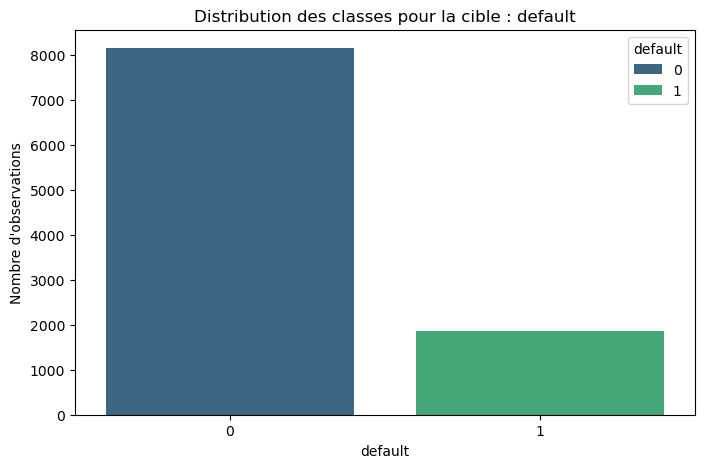

In [41]:
target_column = 'default' 

plt.figure(figsize=(8, 5))
sns.countplot(x=target_column, data=df, hue=target_column, palette='viridis')
plt.title(f'Distribution des classes pour la cible : {target_column}')
plt.ylabel('Nombre d\'observations')
plt.show()

In [42]:
print("Proportion des classes :")
print(df[target_column].value_counts(normalize=True)*100)

Proportion des classes :
default
0    81.49
1    18.51
Name: proportion, dtype: float64


In [43]:
# Identification des colonnes textuelles/catégorielles
cat_cols = df.select_dtypes(include=['object', 'category']).columns
print(f"Variables catégorielles identifiées : {list(cat_cols)}")

Variables catégorielles identifiées : []


In [44]:
# on supprime customer_id (pas de pouvoir prédictif)
df = df.drop(columns=["customer_id"])

In [45]:
# Séparer features et cible
X = df.drop(columns=["default"])
y = df["default"]

In [46]:
# Division train/test (80/20) avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [47]:
print(f"Train : {X_train.shape[0]} observations")
print(f"Test  : {X_test.shape[0]} observations")
print(f"\nDistribution avant SMOTE :")
print(y_train.value_counts())

Train : 8000 observations
Test  : 2000 observations

Distribution avant SMOTE :
default
0    6519
1    1481
Name: count, dtype: int64


In [48]:
print(f"\nDistribution du test :")
print(y_test.value_counts())


Distribution du test :
default
0    1630
1     370
Name: count, dtype: int64


In [49]:
# Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # fit uniquement sur le train

In [50]:
# SMOTE sur le jeu d'entraînement uniquement
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

In [51]:
print(f"\nDistribution après SMOTE :")
print(pd.Series(y_train_resampled).value_counts())
print(f"Nouvelles dimensions du train : {X_train_resampled.shape}")


Distribution après SMOTE :
default
1    6519
0    6519
Name: count, dtype: int64
Nouvelles dimensions du train : (13038, 6)
